In [35]:
import time 
import warnings
import numpy as np 
import pandas as pd
import requests
import matplotlib.pyplot as plt

import torch
import torch.nn as nn # for the neuro network 
from torch.utils.data import TensorDataset, DataLoader 
from sklearn.linear_model import Ridge 

In [36]:
import requests, pandas as pd, time

url = "https://api.binance.com/api/v3/klines"
res = requests.get(url, params={
    "symbol": "BTCUSDT", "interval": "1h", "limit": 1000
}).json()

# Print the first row — see what Binance sends you
print(res[0])

[1787101200000, '64488.00000000', '64551.47000000', '64389.27000000', '64400.48000000', '314.28140000', 1787104799999, '20261820.13558840', 75477, '184.17169000', '11875012.69033680', '0']


In [37]:
columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
]
df = pd.DataFrame(res,columns= columns)
print(df.head())

       open_time            open            high             low  \
0  1787101200000  64488.00000000  64551.47000000  64389.27000000   
1  1787104800000  64400.47000000  64414.65000000  64350.00000000   
2  1787108400000  64351.86000000  64414.00000000  64278.00000000   
3  1787112000000  64330.70000000  64391.80000000  64293.43000000   
4  1787115600000  64316.22000000  64409.93000000  64236.00000000   

            close        volume     close_time quote_asset_volume  \
0  64400.48000000  314.28140000  1787104799999  20261820.13558840   
1  64351.90000000  547.93834000  1787108399999  35282299.56928000   
2  64330.71000000  258.70445000  1787111999999  16645879.68441740   
3  64316.22000000  402.06932000  1787115599999  25874122.96685750   
4  64236.01000000  258.31718000  1787119199999  16619607.44597930   

   number_of_trades taker_buy_base_asset_volume taker_buy_quote_asset_volume  \
0             75477                184.17169000            11875012.69033680   
1             54

In [38]:
df = df.drop(columns = ["ignore"])

In [39]:
print(df.head())

       open_time            open            high             low  \
0  1787101200000  64488.00000000  64551.47000000  64389.27000000   
1  1787104800000  64400.47000000  64414.65000000  64350.00000000   
2  1787108400000  64351.86000000  64414.00000000  64278.00000000   
3  1787112000000  64330.70000000  64391.80000000  64293.43000000   
4  1787115600000  64316.22000000  64409.93000000  64236.00000000   

            close        volume     close_time quote_asset_volume  \
0  64400.48000000  314.28140000  1787104799999  20261820.13558840   
1  64351.90000000  547.93834000  1787108399999  35282299.56928000   
2  64330.71000000  258.70445000  1787111999999  16645879.68441740   
3  64316.22000000  402.06932000  1787115599999  25874122.96685750   
4  64236.01000000  258.31718000  1787119199999  16619607.44597930   

   number_of_trades taker_buy_base_asset_volume taker_buy_quote_asset_volume  
0             75477                184.17169000            11875012.69033680  
1             5486

In [40]:
df["timetamp"] = pd.to_datetime(df["open_time"] , unit="ms" , utc=True )

for c in [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"
]: 
    df[c] = df[c].astype(float) # so here we can convert the data type into float


In [41]:
df = df.sort_values("timetamp").drop_duplicates("timetamp").reset_index(drop=True) 
# so here the sort values make the time sorted in stead of make the 11 pm and 1 am look close it make it look distant as it should so the module can understand 
# and for the drop it drop duplicates 
#utc = true for when i drop the column 5 it get replaced with the next one instead of being null 

In [42]:
print(df.columns.tolist())

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'timetamp']


In [43]:
print(df[["volume", "quote_asset_volume"]].describe())
print(f"Mean price implied: {(df['quote_asset_volume'] / df['volume']).mean():.0f}")

print(df["number_of_trades"].describe())

violations = (df["taker_buy_base_asset_volume"] > df["volume"] * 1.001).sum()
print(f"Violations: {violations}")   

df["taker_buy_ratio"] = (
    df["taker_buy_base_asset_volume"] / (df["volume"] + 1e-8)
)
print(df["taker_buy_ratio"].describe())  

            volume  quote_asset_volume
count  1000.000000        1.000000e+03
mean    728.435558        5.748438e+07
std     690.652387        5.316405e+07
min      67.341680        5.203129e+06
25%     344.379125        2.720248e+07
50%     531.044805        4.162709e+07
75%     848.835883        6.705415e+07
max    9262.869650        6.284078e+08
Mean price implied: 79189
count      1000.00000
mean     142490.88700
std      113735.06177
min       15867.00000
25%       68439.50000
50%      109904.00000
75%      175952.00000
max      912256.00000
Name: number_of_trades, dtype: float64
Violations: 0
count    1000.000000
mean        0.495935
std         0.081907
min         0.236964
25%         0.443968
50%         0.495170
75%         0.552537
max         0.796411
Name: taker_buy_ratio, dtype: float64


In [44]:
df["return"] = ((df["close"]-df["open"] )/df["open"] )*100

In [45]:
df["hourly_range"] = (df["high"] - df["low"]) / df["low"] * 100

In [46]:
#close-to-close return:
#(Ci - Ci-1) / Ci-1 * 100 
df["rt_cc"] = ((df["close"] - df["close"].shift(1)) / df["close"].shift(1)) * 100

In [47]:
df["range_ma_24"] = df["hourly_range"].rolling(24).mean() # moving average of 24 hour range 
df["range_ma_168"] = df["hourly_range"].rolling(168).mean() # moving average of 168 hour range

In [48]:
df["volatility_24"] = df["rt_cc"].rolling(24).std()

In [49]:
df["volume_ma_24"] = df["volume"].rolling(24).mean()
df["volume_ratio"] = df["volume"] / (df["volume_ma_24"] + 1e-8)

In [50]:
#cyclical time encoding:(its an important concept for seprating between the 23 pm  and 1 am )
tau = 2 * np.pi  # Full circle constant (2 * pi)

hour = df["timetamp"].dt.hour
dow = df["timetamp"].dt.dayofweek

df[["hour_sin", "hour_cos"]] = np.column_stack(
    [np.sin(tau * hour / 24), np.cos(tau * hour / 24)]
)

df[["dow_sin", "dow_cos"]] = np.column_stack(
    [np.sin(tau * dow / 7), np.cos(tau * dow / 7)]
)

In [51]:
df["volume_change"] = df["volume"].pct_change() * 100

df["range_ma_720"] = df["hourly_range"].rolling(720).mean()
df["volatility_168"] = df["rt_cc"].rolling(168).std()

df["ma_24_price"]  = df["close"].rolling(24).mean()
df["ma_168_price"] = df["close"].rolling(168).mean()
df["distance_ma_24"]  = (df["close"] - df["ma_24_price"])  / (df["ma_24_price"]  + 1e-8)
df["distance_ma_168"] = (df["close"] - df["ma_168_price"]) / (df["ma_168_price"] + 1e-8)

for lag in (1, 2, 3, 6, 12):
    df[f"range_lag_{lag}"] = df["hourly_range"].shift(lag)

df["is_weekend"] = (df["timetamp"].dt.dayofweek >= 5).astype(float)

In [52]:
df["taker_buy_ratio"] = (
    df["taker_buy_base_asset_volume"] / (df["volume"] + 1e-8)
)
df["order_flow_imbalance"] = (
    (2 * df["taker_buy_base_asset_volume"] - df["volume"])
    / (df["volume"] + 1e-8)
)
df["avg_trade_size"]     = df["volume"] / (df["number_of_trades"] + 1e-8)
df["avg_trade_size_usd"] = df["quote_asset_volume"] / (df["number_of_trades"] + 1e-8)

In [53]:
df["vol_regime"]      = df["volatility_24"] / (df["volatility_168"] + 1e-8)
df["range_vs_ma_168"] = df["hourly_range"] / (df["range_ma_168"] + 1e-8)
df["range_vs_ma_720"] = df["hourly_range"] / (df["range_ma_720"] + 1e-8)

df["high_vol_streak"] = (
    (df["hourly_range"] > df["range_ma_24"]).rolling(6).sum()
)

df["roll_max_720"]  = df["close"].rolling(720).max()
df["drawdown_720"]  = (df["close"] - df["roll_max_720"]) / (df["roll_max_720"] + 1e-8)

df["return_skew_168"] = df["rt_cc"].rolling(168).skew()

In [54]:
df["trade_count_change"] = df["number_of_trades"].pct_change() * 100

In [55]:
df["vwap_hour"]     = df["quote_asset_volume"] / (df["volume"] + 1e-8)
df["close_vs_vwap"] = (df["close"] - df["vwap_hour"]) / (df["vwap_hour"] + 1e-8) * 100

In [56]:
df["ofi_ma_24"]        = df["order_flow_imbalance"].rolling(24).mean()
df["ofi_std_24"]       = df["order_flow_imbalance"].rolling(24).std()
df["taker_buy_ma_24"]  = df["taker_buy_ratio"].rolling(24).mean()
df["trade_size_ma_24"] = df["avg_trade_size"].rolling(24).mean()
df["trade_size_ratio"] = df["avg_trade_size"] / (df["trade_size_ma_24"] + 1e-8)

In [57]:
for lag in (1, 2, 3):
    df[f"trade_ratio_lag_{lag}"] = df["taker_buy_ratio"].shift(lag)

In [58]:
for lag in (1, 2, 3, 6, 12):
    df[f"ofi_lag_{lag}"] = df["order_flow_imbalance"].shift(lag)

In [59]:
df["next_hour_range"] = df["hourly_range"].shift(-1)

In [60]:
df["target"] = df["next_hour_range"] / (df["range_ma_24"] + 1e-8)
df["target"] = df["target"].clip(0, 100)

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'timetamp']

In [61]:
def fetch_funding(start_ms, end_ms):
    records, cur_time = [], start_ms
    while cur_time < end_ms:
        res = requests.get("https://fapi.binance.com/fapi/v1/fundingRate",
                           params={"symbol": "BTCUSDT",
                                   "startTime": cur_time, "limit": 1000},
                           timeout=10)
        data = res.json()
        if not data:
            break
        records.extend(data)
        cur_time = data[-1]["fundingTime"] + 1
        time.sleep(0.02)

    df_f = pd.DataFrame(records)
    df_f["timestamp"] = pd.to_datetime(df_f["fundingTime"], unit="ms", utc=True)
    df_f["funding_rate"] = df_f["fundingRate"].astype(float)
    df_f["funding_rate_change"] = df_f["funding_rate"].diff()
    mean_8h = df_f["funding_rate"].rolling(21, min_periods=7).mean()
    std_8h  = df_f["funding_rate"].rolling(21, min_periods=7).std() + 1e-8
    df_f["z_funding"] = (df_f["funding_rate"] - mean_8h) / std_8h
    return df_f[["timestamp", "funding_rate", "funding_rate_change", "z_funding"]]

start_ms = int(df["timetamp"].min().timestamp() * 1000)
end_ms   = int(df["timetamp"].max().timestamp() * 1000)
df_funding = fetch_funding(start_ms, end_ms)

df = pd.merge_asof(df.sort_values("timetamp"),
                   df_funding.sort_values("timestamp"),
                   left_on="timetamp", right_on="timestamp",
                   direction="backward")

df[["funding_rate", "funding_rate_change", "z_funding"]] = (
    df[["funding_rate", "funding_rate_change", "z_funding"]].ffill().fillna(0)
)



In [62]:
cols_ohlcv = [
    "return",              
    "hourly_range",       
    "rt_cc",            
    "volume_change",       
    "volume_ratio",    
    "range_ma_24",
    "range_ma_168",
    "range_ma_720",
    "volatility_24",
    "volatility_168",
    "distance_ma_24",
    "distance_ma_168",
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "is_weekend",
    "range_lag_1", "range_lag_2", "range_lag_3",
    "range_lag_6", "range_lag_12",
    "vol_regime",
    "range_vs_ma_168",
    "range_vs_ma_720",
    "high_vol_streak",
    "drawdown_720",
    "return_skew_168",
]
cols_orderflow = [
    "taker_buy_ratio",         
    "order_flow_imbalance",   
    "close_vs_vwap",          
    "avg_trade_size",         
    "avg_trade_size_usd",     
    "trade_size_ratio",       
    "trade_count_change", 
    "ofi_ma_24",
    "ofi_std_24",
    "taker_buy_ma_24",
    "trade_size_ma_24",
    "ofi_lag_1", "ofi_lag_2", "ofi_lag_3", "ofi_lag_6", "ofi_lag_12",
    "trade_ratio_lag_1", "trade_ratio_lag_2", "trade_ratio_lag_3",
]

cols_funding = ["funding_rate", "funding_rate_change", "z_funding"]

feature_cols = cols_ohlcv + cols_orderflow + cols_funding

to make a mlp :

layer one : linear transformation 
x*W + b = z

there is vector (x) [ x , y , z] * weights (W) [[ x1 , y1 , z1 ] , [ x2 , y2 , z2 ] ,[ x3 , y3 , z3 ]] + bias (b) [ x , y , z ]  = linear output(z)

so here we using linear algebra to solve this one 

ReLU activation function 

neuron if its zero is clipped (disactivated)
neuron if its between 1 and bigger than zero it active

as example neuron a1,1 max(0 , 0.45) active 
           neuron a1,2 max(0 , -0.23)clipped 

layer 2 : output trasformation 
ŷ = a1 W2 + b2


Step-by-Step Mathematical Flow :
Here is how a 1D feature vector $x$ moves through the 2-layer pipeline:
Linear Projection 1:$$z_1 = x W_1 + b_1$$

Maps your raw input features $x$ into a hidden representation $z_1$.

Nonlinear Filtering (ReLU):
$$a_1 = \max(0, z_1)$$
Zeros out negative activation values element-wise, giving the network the ability to fit non-linear patterns.

Final Linear Projection:
$$\hat{y} = a_1 W_2 + b_2$$
Combines the filtered hidden features into your final scalar prediction $\hat{y}$ (such as next-hour volatility).

In [63]:
needed = feature_cols + ["target"]
df_clean = df.dropna(subset=needed).reset_index(drop=True)

print("Total rows:", len(df_clean))
print("Features:", len(feature_cols))
print("First date:", df_clean["timetamp"].min())
print("Last date: ", df_clean["timetamp"].max())

Total rows: 280
Features: 50
First date: 2026-09-18 00:00:00+00:00
Last date:  2026-09-29 15:00:00+00:00


In [64]:
split_point = int(len(df_clean) * 0.8)

x = df_clean[feature_cols].values.astype("float32")
y = df_clean["target"].values.astype("float32")  

x_train = x[:split_point]
x_test  = x[split_point:]
y_train = y[:split_point]
y_test  = y[split_point:]

In [ ]:
mean = x_train.mean(axis=0)
std  = x_train.std(axis=0) + 1e-8

x_train = (x_train - mean) / std
x_test  = (x_test  - mean) / std

y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

print("X_train shape:", x_train.shape)
print("X_test shape: ", x_test.shape)


X_train shape: (224, 50)
X_test shape:  (56, 50)


$$z = \frac{x - \mu}{\sigma}$$Where:$x$ is the original value.$\mu$ (mu) is the mean (average) of that feature across the training set.$\sigma$ (sigma) is the standard deviation.Step 1: Assume Training StatisticsSuppose we have a training set of student records with these calculated statistics:SAT Score ($X_1$):Mean ($\mu_1$) = 1000Standard Deviation ($\sigma_1$) = 200GPA ($X_2$):Mean ($\mu_2$) = 3.0Standard Deviation ($\sigma_2$) = 0.5Step 2: Unscaled Raw Input ComparisonLet's evaluate a high-performing student with:SAT Score: $1400$GPA: $4.0$If passed directly to a model with equal weights ($w_1 = 1, w_2 = 1$):SAT contribution = $1400$GPA contribution = $4.0$The raw SAT value completely drowns out the GPA value simply due to scale.Step 3: Calculate Standardized Values ($z$-scores)1. Standardizing SAT Score ($1400$)$$z_{\text{SAT}} = \frac{1400 - 1000}{200} = \frac{400}{200} = 2.0$$2. Standardizing GPA ($4.0$)$$z_{\text{GPA}} = \frac{4.0 - 3.0}{0.5} = \frac{1.0}{0.5} = 2.0$$Final ResultFeatureRaw ValueMean (μ)Std Dev (σ)Scaled Value (z)MeaningSAT14001000200$+2.0$2 std devs above averageGPA4.03.00.5$+2.0$2 std devs above averageAfter applying (X - mean) / std, both values equal $+2.0$. The model now views both achievements as equally impressive relative to their respective distributions.

In [ ]:
model = nn.Sequential(
    nn.Linear(len(feature_cols), 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)
# Weights: 48*32 = 1,536    Biases:32              Total parameters in Layer 1: 1,568 trainable numbers

print(model)

Sequential(
  (0): Linear(in_features=50, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)


In [75]:

X_t = torch.tensor(x_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

loader = DataLoader(TensorDataset(x_t, y_t), batch_size=128, shuffle=True)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [76]:
for epoch in range(30):
    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad()       
        preds = model(xb)            
        loss = loss_fn(preds, yb)    
        loss.backward()             
        optimizer.step()       

        total_loss += loss.item()

    avg = total_loss / len(loader)
    print("epoch", epoch + 1, "| loss", round(avg, 5))

epoch 1 | loss 0.09524
epoch 2 | loss 0.08475
epoch 3 | loss 0.07706
epoch 4 | loss 0.07582
epoch 5 | loss 0.06947
epoch 6 | loss 0.06651
epoch 7 | loss 0.06527
epoch 8 | loss 0.06211
epoch 9 | loss 0.05763
epoch 10 | loss 0.05569
epoch 11 | loss 0.05397
epoch 12 | loss 0.05295
epoch 13 | loss 0.0522
epoch 14 | loss 0.05161
epoch 15 | loss 0.04659
epoch 16 | loss 0.0483
epoch 17 | loss 0.04609
epoch 18 | loss 0.04432
epoch 19 | loss 0.0435
epoch 20 | loss 0.04123
epoch 21 | loss 0.0429
epoch 22 | loss 0.04026
epoch 23 | loss 0.03882
epoch 24 | loss 0.03714
epoch 25 | loss 0.03701
epoch 26 | loss 0.03529
epoch 27 | loss 0.03398
epoch 28 | loss 0.03355
epoch 29 | loss 0.03357
epoch 30 | loss 0.0331


In [77]:
with torch.no_grad():
    x_test_t = torch.tensor(x_test)
    preds_log = model(x_test_t).numpy().flatten()

preds = np.expm1(preds_log)

def r2(real, guess):
    top    = ((real - guess) ** 2).sum()
    bottom = ((real - real.mean()) ** 2).sum()
    return 1 - top / bottom

nn_r2    = r2(y_test, preds)
naive    = np.full(len(y_test), y_train.mean())
naive_r2 = r2(y_test, naive)

print("NN R²:    ", round(nn_r2, 4))
print("Naive R²: ", round(naive_r2, 4))

NN R²:     -1.5944
Naive R²:  -0.2121


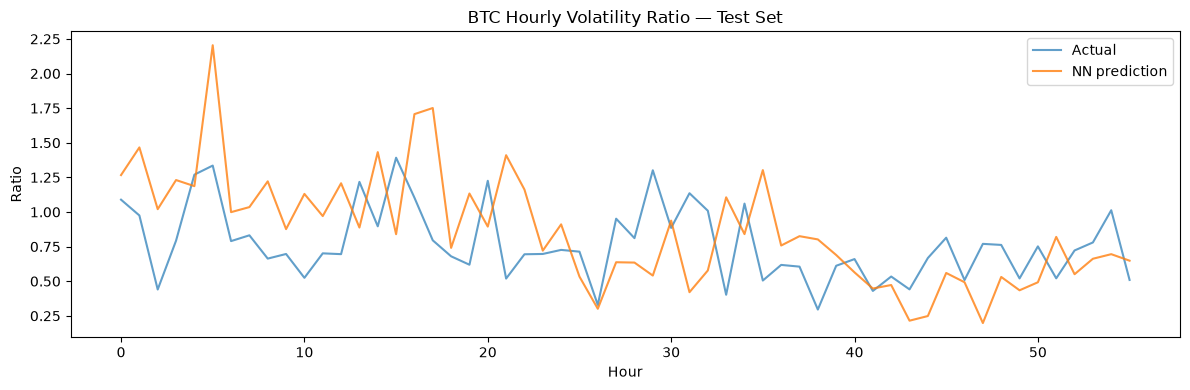

In [78]:
n = 300   

plt.figure(figsize=(12, 4))
plt.plot(y_test[:n], label="Actual", alpha=0.7)
plt.plot(preds[:n], label="NN prediction", alpha=0.8)
plt.title("BTC Hourly Volatility Ratio — Test Set")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()